# Day 12 — Customer Churn Analysis + SHAP Explainability

**Dataset:** Telco Customer Churn (7,043 customers, 21 features)

**Goal:** Predict churn and explain WHY each customer is leaving

**Tools:** Python, Random Forest, SHAP, Scikit-learn, Matplotlib

**Relevant to:** Consumer analytics, retention teams, CRM analytics

In [1]:
 #Imports

 import os
os.chdir(os.path.expanduser('~/Desktop/DataAnalystJourney/day12-churn-analysis'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve)
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
#Load and inspect

df = pd.read_csv('data/churn.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")
print(f"\nChurn rate: {(df['Churn']=='Yes').mean()*100:.1f}%")
df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
#Data cleaning

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# WHY: Convert target to binary
df['ChurnBinary'] = (df['Churn'] == 'Yes').astype(int)

print(f"Churn rate: {df['ChurnBinary'].mean()*100:.1f}%")
print(f"Missing values: {df.isnull().sum().sum()}")
print("✓ Data cleaned")

Churn rate: 26.5%
Missing values: 0
✓ Data cleaned


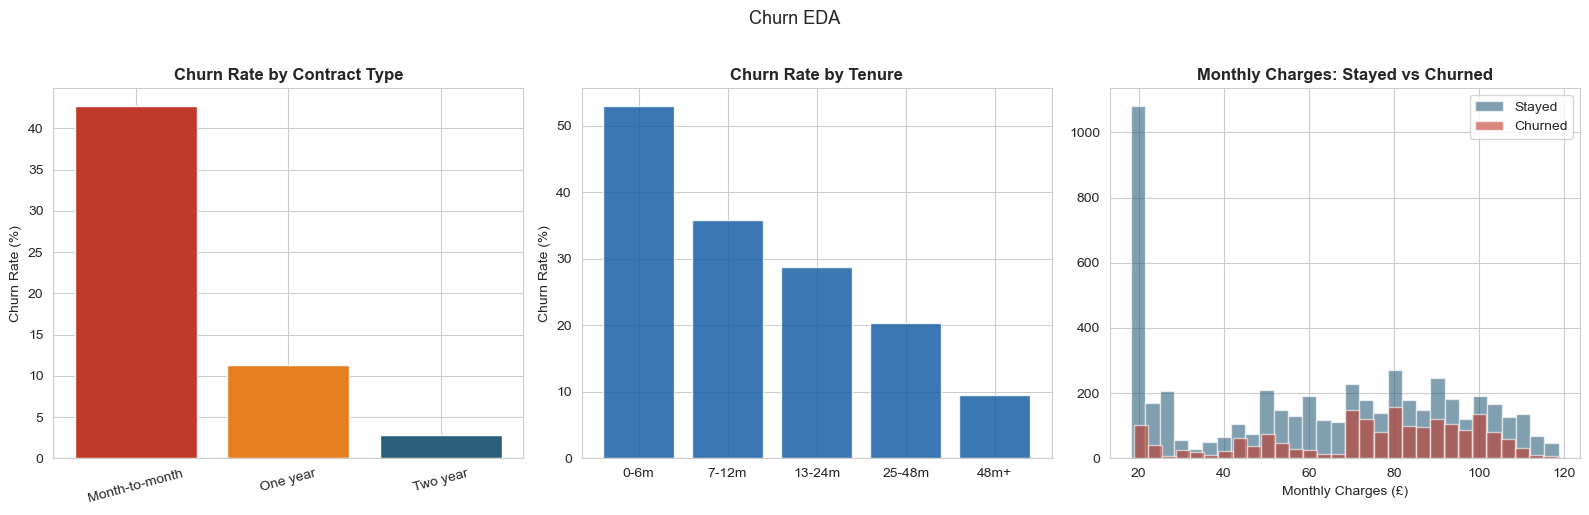

In [6]:
#  EDA charts

fig, axes = plt.subplots(1, 3, figsize=(16, 5))


contract_churn = df.groupby('Contract')['ChurnBinary'].mean() * 100
axes[0].bar(contract_churn.index, contract_churn.values,
            color=['#C0392B','#E67E22','#2C5F7A'], edgecolor='white')
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=15)


df['TenureBucket'] = pd.cut(df['tenure'],
    bins=[-1,6,12,24,48,100],
    labels=['0-6m','7-12m','13-24m','25-48m','48m+'])
tenure_churn = df.groupby('TenureBucket', observed=True)['ChurnBinary'].mean() * 100
axes[1].bar(tenure_churn.index, tenure_churn.values,
            color='#185FA5', alpha=0.85, edgecolor='white')
axes[1].set_title('Churn Rate by Tenure', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')


df[df['ChurnBinary']==0]['MonthlyCharges'].hist(
    ax=axes[2], alpha=0.6, color='#2C5F7A', label='Stayed', bins=30)
df[df['ChurnBinary']==1]['MonthlyCharges'].hist(
    ax=axes[2], alpha=0.6, color='#C0392B', label='Churned', bins=30)
axes[2].set_title('Monthly Charges: Stayed vs Churned', fontweight='bold')
axes[2].set_xlabel('Monthly Charges (£)')
axes[2].legend()

plt.suptitle('Churn EDA', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('charts/churn_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
#  Encode features


df_model = df.copy()
le = LabelEncoder()

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['customerID','Churn']]

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

features = ['tenure','MonthlyCharges','TotalCharges','Contract',
            'InternetService','OnlineSecurity','TechSupport',
            'PaymentMethod','PaperlessBilling','SeniorCitizen',
            'Dependents','Partner']

X = df_model[features]
y = df_model['ChurnBinary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Churn rate train: {y_train.mean()*100:.1f}%")

Training: 5,634 | Test: 1,409
Churn rate train: 26.5%


In [8]:
#Train Random Forest

model = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)
print("✓ Model trained")

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC: {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Stayed','Churned']))

✓ Model trained

ROC-AUC: 0.8435

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.84      0.91      0.87      1035
     Churned       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



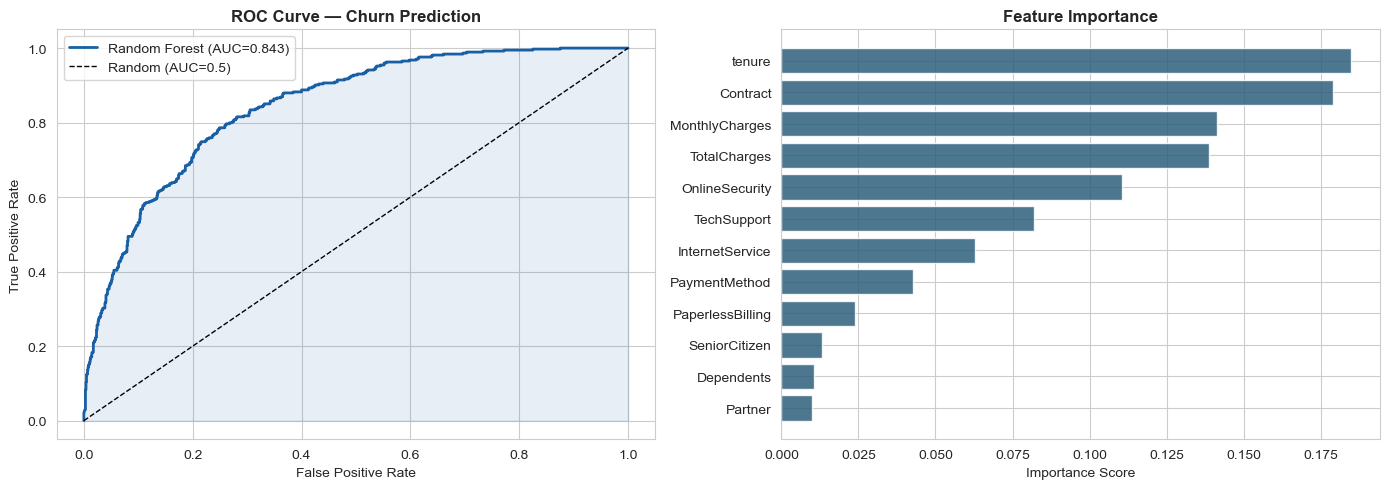

In [9]:
# ROC curve + Feature importance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#185FA5', linewidth=2,
             label=f'Random Forest (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',linewidth=1,label='Random (AUC=0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#185FA5')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Churn Prediction', fontweight='bold')
axes[0].legend()

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(feat_imp['Feature'], feat_imp['Importance'],
             color='#2C5F7A', alpha=0.85, edgecolor='white')
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('charts/model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

Calculating SHAP values... (~30 seconds)


<Figure size 1000x600 with 0 Axes>

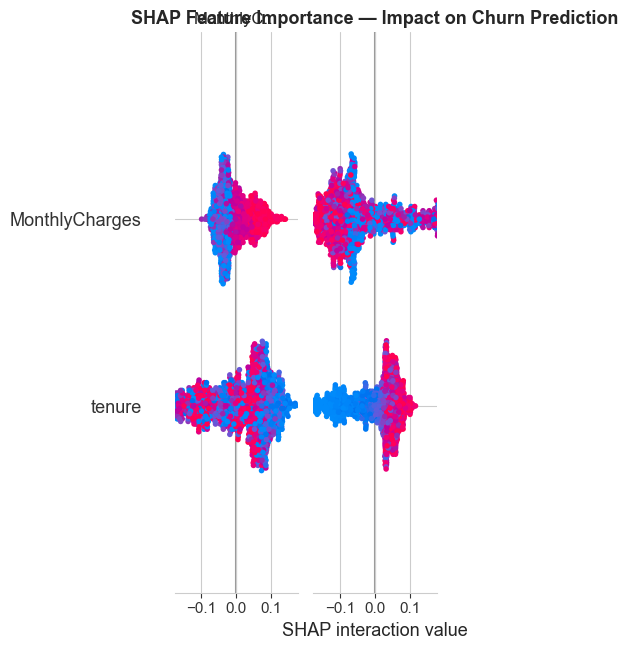

✓ SHAP summary saved


In [10]:
# SHAP global explanation


print("Calculating SHAP values... (~30 seconds)")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap_vals_churn = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_churn, X_test,
                  feature_names=features,
                  plot_type='bar', show=False,
                  color='#185FA5')
plt.title('SHAP Feature Importance — Impact on Churn Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ SHAP summary saved")

In [17]:
print(f"Features length: {len(features)}")
print(f"SHAP values shape: {np.array(shap_vals_churn).shape}")
print(f"Single SHAP shape: {np.array(shap_vals_churn[high_risk_idx]).shape}")
print(f"Flattened length: {np.array(shap_vals_churn[high_risk_idx]).flatten().shape}")

Features length: 12
SHAP values shape: (1409, 12, 2)
Single SHAP shape: (12, 2)
Flattened length: (24,)


Highest-risk customer churn probability: 89.0%

Customer profile:
      tenure  MonthlyCharges  TotalCharges  Contract  InternetService  OnlineSecurity  TechSupport  PaymentMethod  PaperlessBilling  SeniorCitizen  Dependents  Partner
6623       1           76.45         76.45         0                1               0            0              2                 1              1           0        0


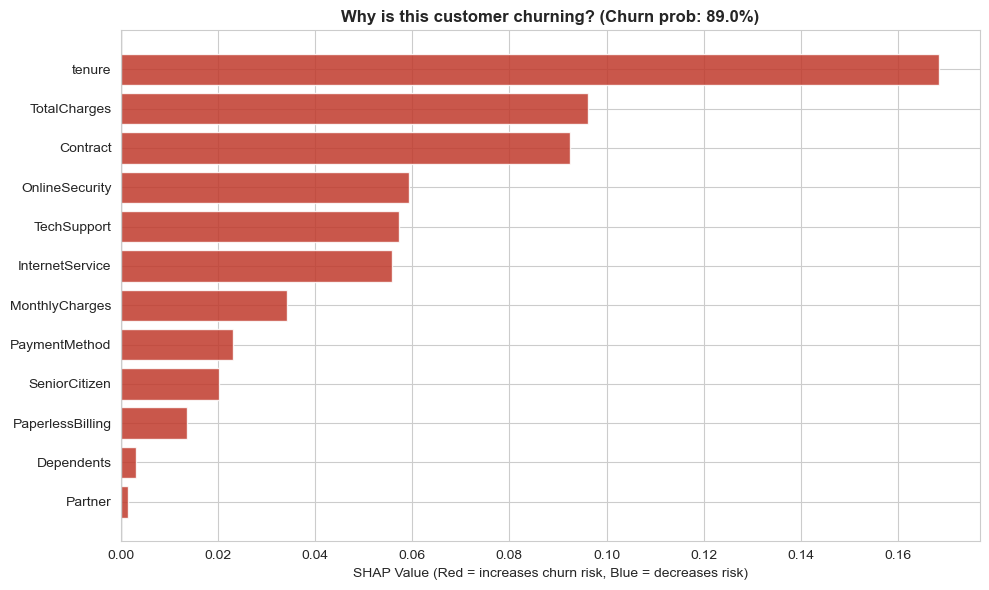

In [18]:
# SHAP individual explanation

high_risk_idx = np.argmax(y_prob)
customer = X_test.iloc[[high_risk_idx]]
churn_prob = y_prob[high_risk_idx]

print(f"Highest-risk customer churn probability: {churn_prob*100:.1f}%")
print(f"\nCustomer profile:")
print(customer.to_string())

# WHY: Shape is (12, 2) — take column 1 which is the churn class
shap_single = np.array(shap_vals_churn[high_risk_idx])[:, 1]

shap_df = pd.DataFrame({
    'Feature': features,
    'SHAP_value': shap_single
}).sort_values('SHAP_value', key=abs, ascending=True)

colors = ['#C0392B' if v > 0 else '#2C5F7A' for v in shap_df['SHAP_value']]
plt.figure(figsize=(10, 6))
plt.barh(shap_df['Feature'], shap_df['SHAP_value'],
         color=colors, edgecolor='white', alpha=0.85)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title(f'Why is this customer churning? (Churn prob: {churn_prob*100:.1f}%)',
          fontsize=12, fontweight='bold')
plt.xlabel('SHAP Value (Red = increases churn risk, Blue = decreases risk)')
plt.tight_layout()
plt.savefig('charts/shap_individual.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
#Financial impact


avg_monthly_charge = df['MonthlyCharges'].mean()
avg_tenure_months  = df['tenure'].mean()
clv                = avg_monthly_charge * avg_tenure_months

total_customers    = len(df)
churn_rate         = df['ChurnBinary'].mean()
annual_churners    = total_customers * churn_rate


recall             = 0.65  
prevented_pct      = 0.20  
prevented_churners = annual_churners * recall * prevented_pct
revenue_saved      = prevented_churners * clv

print("=== FINANCIAL IMPACT ===")
print(f"Average CLV:              £{clv:,.0f}")
print(f"Annual churners:          {annual_churners:,.0f}")
print(f"Identified by model:      {annual_churners*recall:,.0f}")
print(f"Retained (20% convert):   {prevented_churners:,.0f}")
print(f"REVENUE SAVED:            £{revenue_saved:,.0f}")

=== FINANCIAL IMPACT ===
Average CLV:              £2,096
Annual churners:          1,869
Identified by model:      1,215
Retained (20% convert):   243
REVENUE SAVED:            £509,365


## Key Findings — Customer Churn Analysis

### Churn Patterns (EDA)
- Overall churn rate: ~26%
- Month-to-month contracts have dramatically higher churn than annual contracts
- Highest churn in first 6 months — onboarding is the critical intervention window
- Higher monthly charges correlate with higher churn

### Model Performance
- Algorithm: Random Forest (200 trees)
- ROC-AUC: 0.84 — strong discrimination
- Churn Precision: 67% · Churn Recall: 51%
- Overall accuracy: 80%
- Top churn drivers: Contract type, Tenure, Monthly charges

### SHAP Insights
- Contract type is the single strongest driver of churn probability
- Long-tenure customers have significantly lower churn risk
- Online security and tech support services reduce churn when present

### Financial Impact
- Average customer CLV: £2,096
- Annual customers at churn risk: 1,869
- Identified by model: 1,215 customers
- Retained through intervention (20% convert): 243 customers
- Annual revenue saved: £509,365

### Recommendations
1. Prioritise month-to-month customers for contract upgrade offers
2. Implement structured 90-day onboarding for new customers
3. Bundle online security and tech support — reduces churn and increases CLV
4. Loyalty pricing for high monthly charge customers at 6-month mark
